## Exploratory Data Analysis of "New Italian Glacier Inventory"

In [44]:
regions = ["abruzzo", "aosta", "friuli", "lombardy", "piedmont", "south-tyrol", "trentino", "veneto"]
map_region = {
    "abruzzo": "Abruzzo",
    "aosta": "Aosta Valley",
    "friuli": "Friuli Venezia Giulia",
    "lombardy": "Lombardy",
    "piedmont": "Piedmont",
    "south-tyrol": "South Tyrol",
    "trentino": "Trentino",
    "veneto": "Veneto"
}

In [45]:
import pandas as pd
import matplotlib.pyplot as plt

df_italy = pd.read_csv(f"../data/unimi/{regions[0]}-unimi.csv", header=0, dtype={'ID Code': str})
df_italy['Region'] = map_region[regions[0]]
df_italy.head()

for r in regions[1:]:
    # print("region", r)
    df_region = pd.read_csv(f"../data/unimi/{r}-unimi.csv", header=0, dtype={'ID Code': str})
    df_region['Region'] = map_region[r]
    df_italy = pd.concat([df_italy, df_region], ignore_index=True)
    print(f'{r}   \t Rows added:{len(df_region)}   \t Total rows df_italy:{len(df_italy)}')


aosta   	 Rows added:192   	 Total rows df_italy:194
friuli   	 Rows added:7   	 Total rows df_italy:201
lombardy   	 Rows added:230   	 Total rows df_italy:431
piedmont   	 Rows added:107   	 Total rows df_italy:538
south-tyrol   	 Rows added:213   	 Total rows df_italy:751
trentino   	 Rows added:116   	 Total rows df_italy:867
veneto   	 Rows added:38   	 Total rows df_italy:905


In [46]:
df_italy['Area (km2)'] = pd.to_numeric(df_italy['Area (km2)'], errors='coerce')
df_italy['Area CGI (km2)'] = pd.to_numeric(df_italy['Area CGI (km2)'], errors='coerce')
df_italy['Area WGI (km2)'] = pd.to_numeric(df_italy['Area WGI (km2)'], errors='coerce')
df_italy['Year'] = pd.to_numeric(df_italy['Year'], errors='coerce').astype('Int64')
df_italy['ID Code'] = df_italy['ID Code'].astype(str)
df_italy['Newly Formed'] = df_italy['ID Code'].str.contains('\.')
print("Area columns converted to numeric and 'Newly Formed' column created.")
# df_italy.head(4)

Area columns converted to numeric and 'Newly Formed' column created.


In [47]:
sector_counts = df_italy['Mountain Sector'].value_counts().sort_values(ascending=False)
print(">>> Glacier count by Mountain Sector\n", sector_counts)

>>> Glacier count by Mountain Sector
 Mountain Sector
SOUTHERN RHAETIAN ALPS      269
EASTERN RHAETIAN ALPS       158
GRAIAN ALPS                 152
WESTERN RHAETIAN ALPS       103
PENNINE ALPS                 78
DOLOMITES                    51
BERGAMO ALPS AND PREALPS     42
LEPONTINE ALPS               29
COTTIAN ALPS                  8
JULIAN ALPS                   7
MARITIME ALPS                 6
APENNINES                     2
Name: count, dtype: int64


In [48]:
region_counts = df_italy['Region'].value_counts().sort_values(ascending=False)
print(">>> Glacier count by Political Region\n", region_counts)

>>> Glacier count by Political Region
 Region
Lombardy                 230
South Tyrol              213
Aosta Valley             192
Trentino                 116
Piedmont                 107
Veneto                    38
Friuli Venezia Giulia      7
Abruzzo                    2
Name: count, dtype: int64


In [49]:
import numpy as np
group_counts = df_italy['Mountain Group'].value_counts().sort_values(ascending=False).head(10)
print(">>> Top 10 Glacier count by Mountain Group\n")
top10_group_counts_sectors = []
for group in group_counts.index:
    sector = df_italy[df_italy['Mountain Group'] == group]['Mountain Sector'].iloc[0]
    top10_group_counts_sectors.append(sector)
    count = group_counts[group]
    print(f"{count} \t {group} - {sector}")

>>> Top 10 Glacier count by Mountain Group

121 	 Ortler Alps - SOUTHERN RHAETIAN ALPS
93 	 Adamello-Presanella Alps - SOUTHERN RHAETIAN ALPS
68 	 Grande Sassière-Tsanteleina Chain - GRAIAN ALPS
65 	 Bernina Range - WESTERN RHAETIAN ALPS
55 	 Ötztal Alps - EASTERN RHAETIAN ALPS
52 	 Gran Paradiso Chain - GRAIAN ALPS
51 	 Zillertal Alps - EASTERN RHAETIAN ALPS
41 	 Bergamo Alps and Prealps - BERGAMO ALPS AND PREALPS
40 	 High Tauern (Western Defereggen) - EASTERN RHAETIAN ALPS
34 	 Monte Rosa Massif - PENNINE ALPS


In [50]:
# palette_colors = plt.cm.turbo(np.linspace(0, 1, len(top10_group_counts_sectors)))
palette_colors = plt.cm.BrBG(np.linspace(0.1, 1, len(top10_group_counts_sectors)))
sector_to_color = {sector: color for sector, color in zip(top10_group_counts_sectors, palette_colors)}
sector_to_color

{'SOUTHERN RHAETIAN ALPS': array([0.74901961, 0.50588235, 0.17647059, 1.        ]),
 'GRAIAN ALPS': array([0.78039216, 0.91764706, 0.89803922, 1.        ]),
 'WESTERN RHAETIAN ALPS': array([0.96470588, 0.90980392, 0.76470588, 1.        ]),
 'EASTERN RHAETIAN ALPS': array([0.00384468, 0.39677047, 0.36509035, 1.        ]),
 'BERGAMO ALPS AND PREALPS': array([0.20784314, 0.59215686, 0.56078431, 1.        ]),
 'PENNINE ALPS': array([0.        , 0.23529412, 0.18823529, 1.        ])}

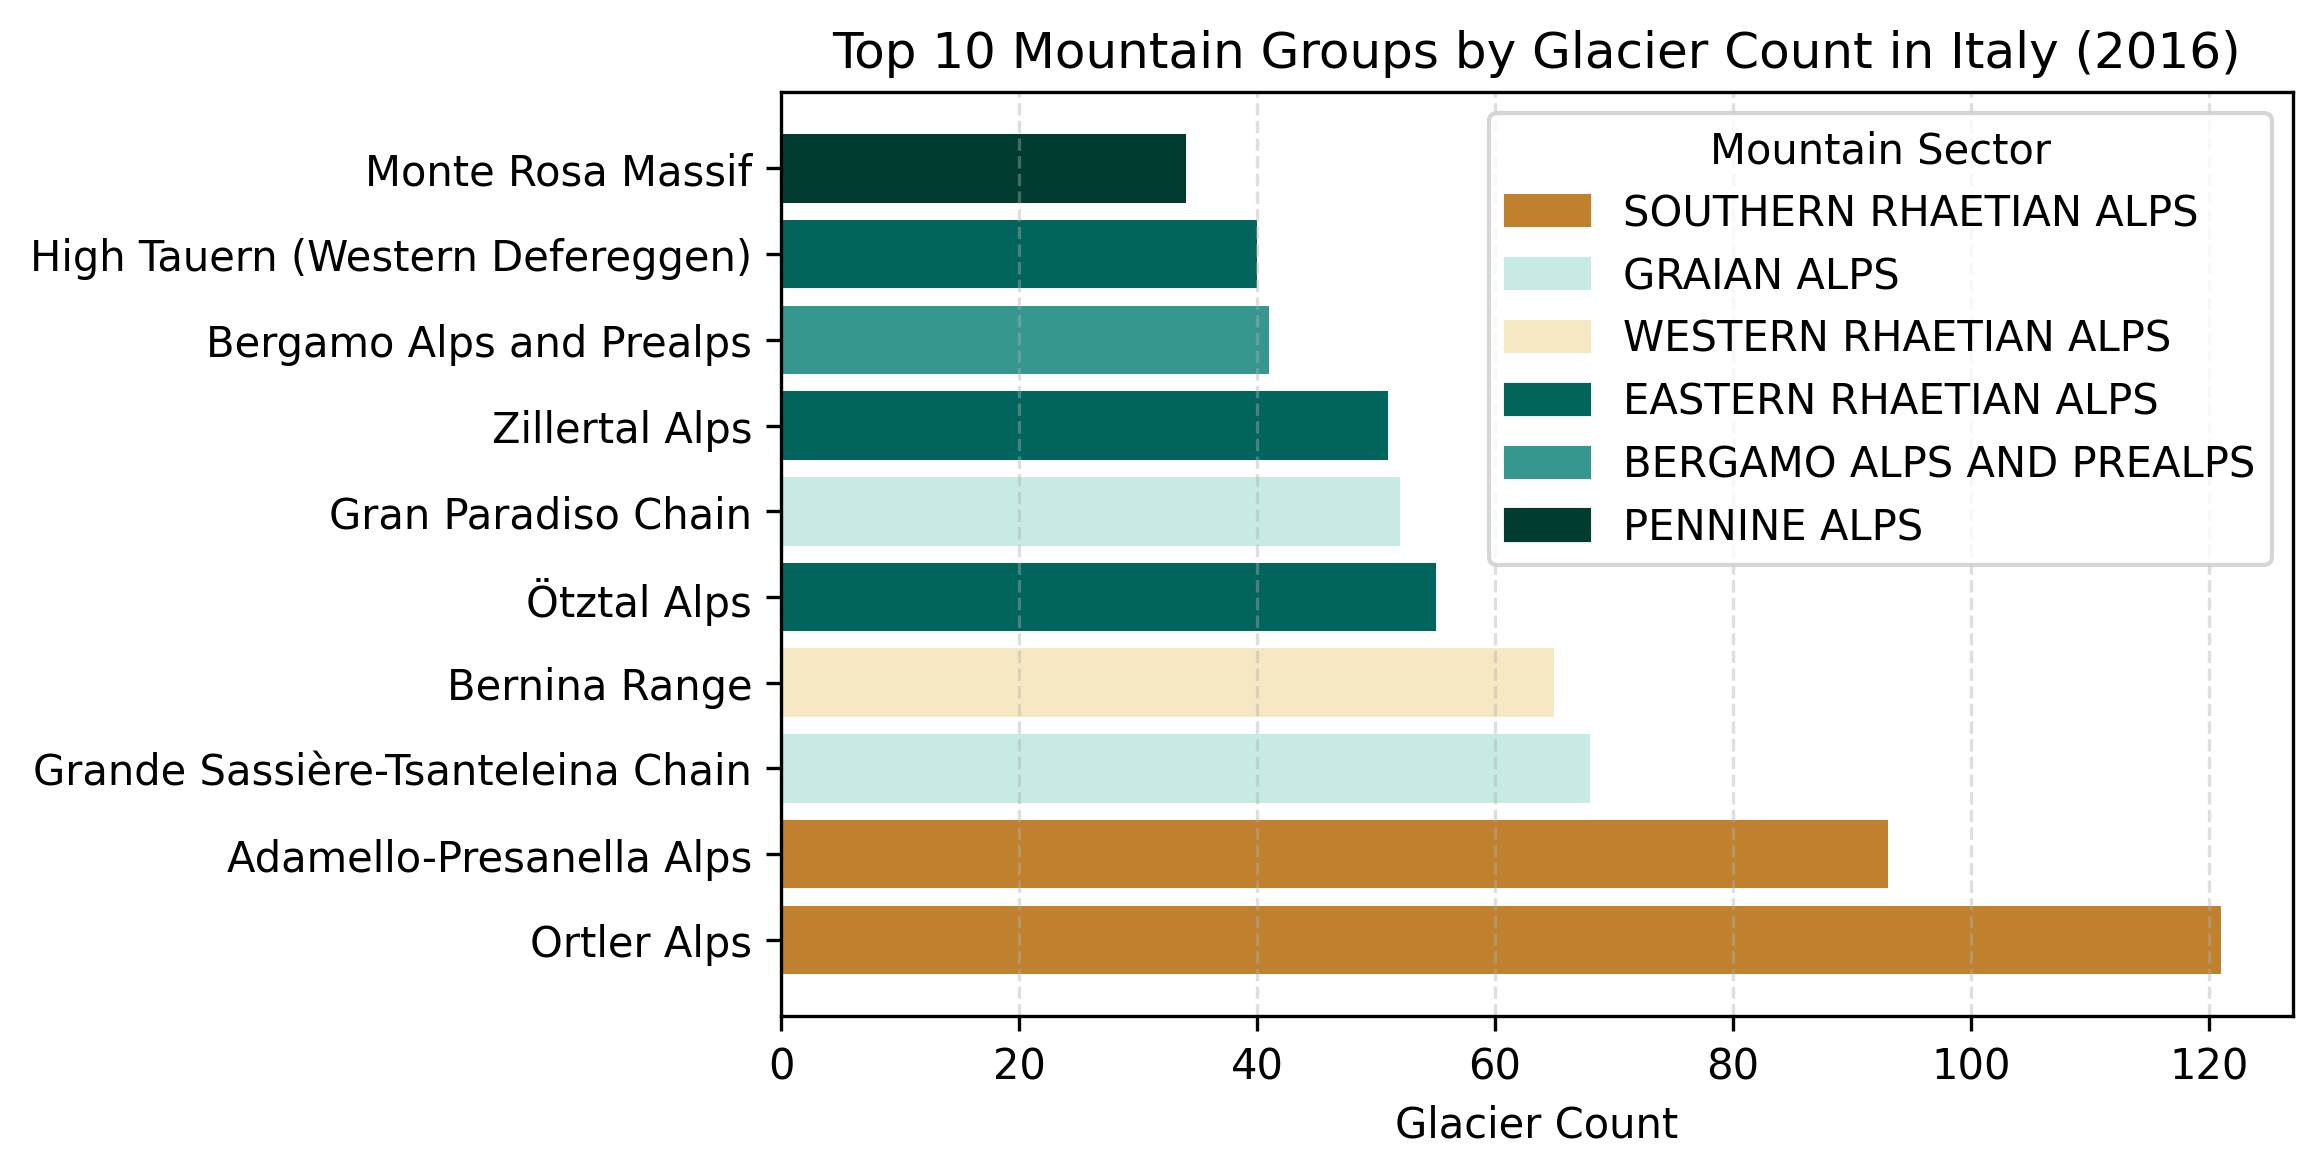

In [51]:
plt.figure(figsize=(6.5, 4), dpi=300)
bars = plt.barh(group_counts.index, group_counts.values, color=[sector_to_color[sector] for sector in top10_group_counts_sectors])
plt.xlabel('Glacier Count')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.title('Top 10 Mountain Groups by Glacier Count in Italy (2016)')
legend_elements = [plt.Rectangle((0, 0), 1, 1, color=color, label=sector) for sector, color in sector_to_color.items()]
plt.legend(handles=legend_elements, title='Mountain Sector')

In [52]:
import numpy as np
group_area = df_italy.groupby('Mountain Group')['Area (km2)'].sum().sort_values(ascending=False).head(10)
print(">>> Top 10 Glacier area by Mountain Group\n")
top10_group_area_sectors = []
for group in group_area.index:
    sector = df_italy[df_italy['Mountain Group'] == group]['Mountain Sector'].iloc[0]
    top10_group_area_sectors.append(sector)
    area = group_area[group]
    print(f"{area:.2f} \t {group} - {sector}")

>>> Top 10 Glacier area by Mountain Group

70.69 	 Ortler Alps - SOUTHERN RHAETIAN ALPS
41.31 	 Adamello-Presanella Alps - SOUTHERN RHAETIAN ALPS
37.96 	 Monte Rosa Massif - PENNINE ALPS
36.85 	 Mont Blanc Massif - WESTERN RHAETIAN ALPS
29.41 	 Bernina Range - WESTERN RHAETIAN ALPS
28.49 	 Grande Sassière-Tsanteleina Chain - GRAIAN ALPS
26.23 	 Gran Paradiso Chain - GRAIAN ALPS
22.21 	 Ötztal Alps - EASTERN RHAETIAN ALPS
15.88 	 Weisshorn-Matterhorn Chain - PENNINE ALPS
9.74 	 High Tauern (Western Defereggen) - EASTERN RHAETIAN ALPS


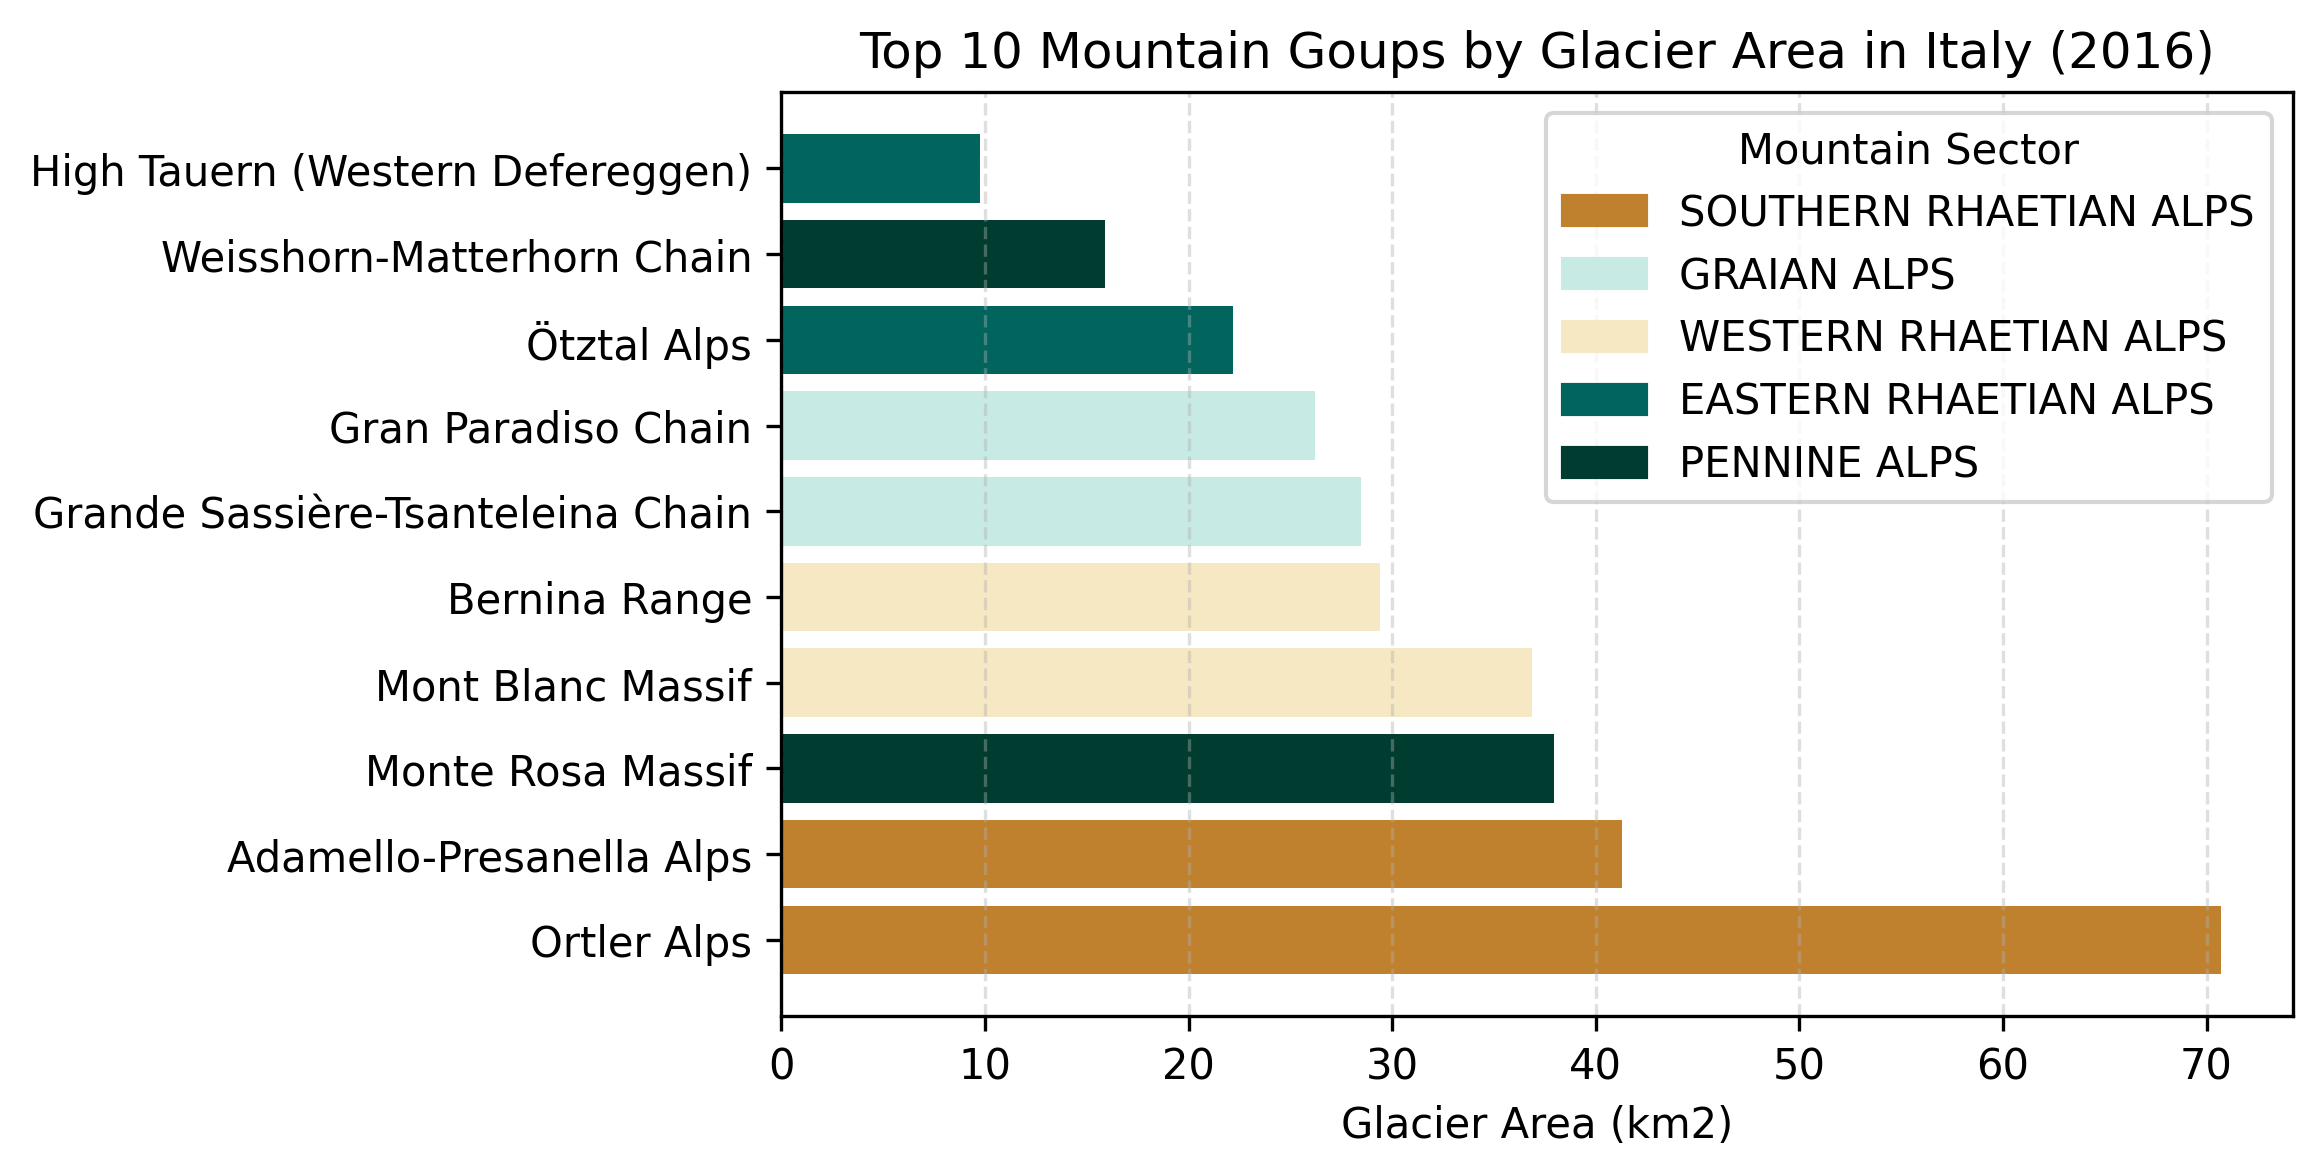

In [53]:
plt.figure(figsize=(6.5, 4), dpi=300)

sector_to_color.pop('BERGAMO ALPS AND PREALPS', None) 

bars = plt.barh(group_area.index, group_area.values, color=[sector_to_color[sector] for sector in top10_group_area_sectors])
plt.xlabel('Glacier Area (km2)')
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.title('Top 10 Mountain Goups by Glacier Area in Italy (2016)')
legend_elements = [plt.Rectangle((0, 0), 1, 1, color=color, label=sector) for sector, color in sector_to_color.items()]
plt.legend(handles=legend_elements, title='Mountain Sector')

In [54]:
sector_area = df_italy.groupby('Mountain Sector') \
            .agg({'Area CGI (km2)': 'sum',
                  'Area WGI (km2)': 'sum',
                  'Area (km2)': 'sum'}).sort_values(by='Area (km2)', ascending=False)
sector_area

,Area CGI (km2),Area WGI (km2),Area (km2)
Mountain Sector,,,
SOUTHERN RHAETIAN ALPS,142.800,166.23,117.91
WESTERN RHAETIAN ALPS,79.140,73.83,67.35
GRAIAN ALPS,80.764,92.56,60.70
PENNINE ALPS,66.903,58.13,57.23
EASTERN RHAETIAN ALPS,74.240,74.92,50.60
LEPONTINE ALPS,9.650,12.62,6.57
DOLOMITES,7.810,7.78,5.04
BERGAMO ALPS AND PREALPS,1.840,2.27,1.95
MARITIME ALPS,2.850,0.67,0.41


### Plots

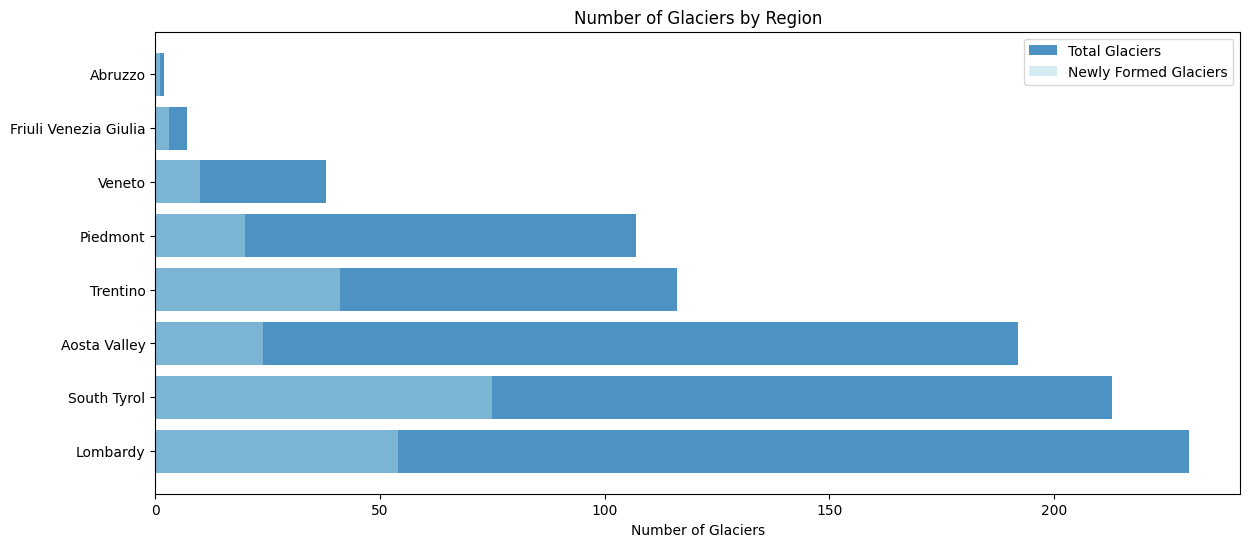

In [55]:
#use two subplots
new_glacier_counts = df_italy.groupby('Region')['Newly Formed'].sum()
region_counts = df_italy['Region'].value_counts()

plt.figure(figsize=(14, 6))
plt.barh(region_counts.index, region_counts.values, label='Total Glaciers', alpha=0.8)
plt.barh(new_glacier_counts.index, new_glacier_counts.values, color="lightblue", alpha=0.5, label='Newly Formed Glaciers')
plt.xlabel('Number of Glaciers')
plt.title('Number of Glaciers by Region')
plt.legend()

In [56]:
df_italy['Mountain Group'].unique()

<ArrowStringArray>
[              'Gran Sasso d'Italia',               'Gran Paradiso Chain',
             'Emilius-Tersiva Chain', 'Grande Sassière-Tsanteleina Chain',
                 'Mont Blanc Massif',                'Grand Combin Chain',
        'Weisshorn-Matterhorn Chain',                 'Monte Rosa Massif',
                       'Julian Alps',                        'Adula Alps',
       'Platta-Unterhalbstein Group',                     'Bernina Range',
                      'Livigno Alps',                       'Ortler Alps',
              'Sobretta-Gavia Group',          'Adamello-Presanella Alps',
          'Bergamo Alps and Prealps',  'Bergamo Alps and Prealps -Venina',
                     'Maritime Alps',                      'Cottian Alps',
     'Rocciamelone-Charbonnel Chain',           'Weissmies-Andolla Chain',
     'Monte Leone-Blinnenhorn Chain',                       'Ötztal Alps',
                       'Stubai Alps',                    'Zillertal Alps',
  'Hig

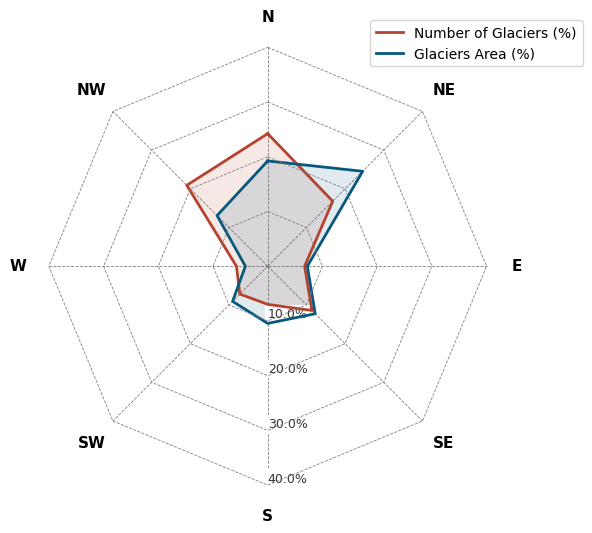

In [418]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick  # Imported for percentage formatting
from matplotlib.path import Path
from matplotlib.spines import Spine

target_df = df_italy.copy()

# Clean and reindex
valid_aspect = target_df['Aspect'].notna() & (target_df['Aspect'].str.strip() != "") & (target_df['Aspect'] != "SW / W")
order = ['N', 'NE', 'E', 'SE', 'S', 'SW', 'W', 'NW']

aspect_num_cleaned = target_df.loc[valid_aspect, 'Aspect'].value_counts().reindex(order, fill_value=0)
aspect_area_cleaned = target_df.loc[valid_aspect].groupby('Aspect')['Area (km2)'].sum().reindex(order, fill_value=0)

# Percentages (guard against zero totals)
pct_num = (aspect_num_cleaned / aspect_num_cleaned.sum() * 100) if aspect_num_cleaned.sum() > 0 else aspect_num_cleaned
pct_area = (aspect_area_cleaned / aspect_area_cleaned.sum() * 100) if aspect_area_cleaned.sum() > 0 else aspect_area_cleaned

# Angles and closed loop
angles = np.linspace(0, 2 * np.pi, len(order), endpoint=False)
angles = np.concatenate((angles, [angles[0]]))
values_num = np.concatenate((pct_num.values, [pct_num.values[0]]))
values_area = np.concatenate((pct_area.values, [pct_area.values[0]]))

# Plot
plt.figure(figsize=(6, 6))
ax = plt.subplot(111, projection='polar')

ax.plot(angles, values_num, linewidth=2, linestyle='solid', color="#b5422e", label='Number of Glaciers (%)')
ax.fill(angles, values_num, alpha=0.12, color="#b5422e")

ax.plot(angles, values_area, linewidth=2, linestyle='solid', color="#07587d", label='Glaciers Area (%)')
ax.fill(angles, values_area, alpha=0.12, color="#07587d")

ax.set_xticks(angles[:-1])
ax.set_xticklabels(order, fontsize=11, fontweight='bold')
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=100))
ax.set_rlabel_position(180)

# Dynamic y-grid up to nearest 10 or at least 40
ymax = max(40, np.ceil(max(values_num.max(), values_area.max()) / 10) * 10)
grid_ticks = list(range(10, int(ymax) + 1, 10))
ax.set_yticks(grid_ticks)
plt.setp(ax.get_yticklabels(), fontsize=9, alpha=0.8, bbox=dict(facecolor='white', edgecolor='none', pad=2))

# Draw straight polygon grid and spokes (preserve octagon look)
ax.spines['polar'].set_visible(False)
ax.grid(False)
for tick in grid_ticks:
    ax.plot(np.linspace(0, 2 * np.pi, len(angles)), [tick] * len(angles), color='grey', linestyle='--', linewidth=0.6)
for angle in angles[:-1]:
    ax.plot([angle, angle], [0, ymax], color='grey', linestyle='--', linewidth=0.6, zorder=0)

plt.legend(loc='upper right', bbox_to_anchor=(1.2, 1.05))
plt.tight_layout()
plt.show()

In [419]:
righe_corrotte = df_italy[~df_italy["Glacier Type"].isin(['Valley', 'Mountain', 'Glacieret'])]

print(f"Trovate {len(righe_corrotte)} righe corrotte:")
print(righe_corrotte[["Glacier Name", "Region", "Glacier Type"]])

Trovate 0 righe corrotte:
Empty DataFrame
Columns: [Glacier Name, Region, Glacier Type]
Index: []


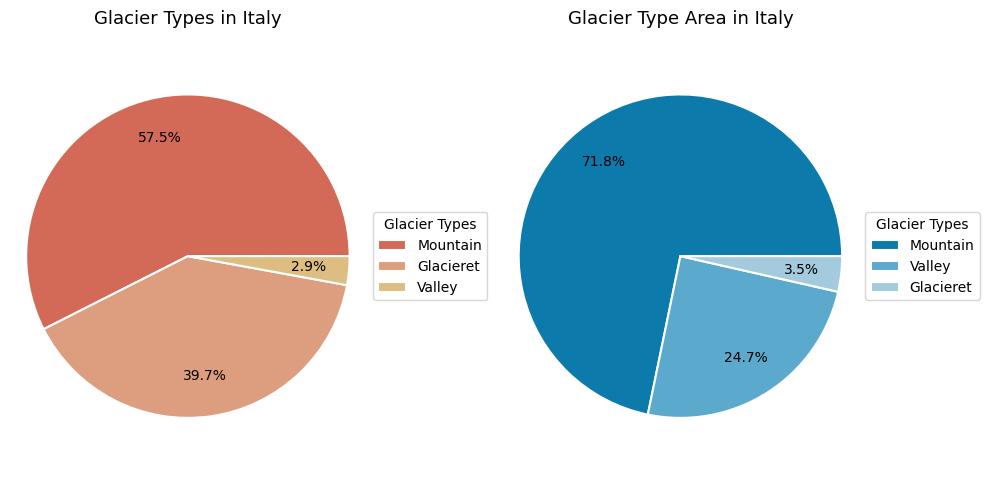

In [440]:
# plt.figure(figsize=(8, 5))
THREE_COL_AREA = ["#0d7aac", "#5ba9cd", "#a3cbdd"]
THREE_COL_COUNT = ["#d26a57", "#dc9e7f", "#ddbd82"]

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# df.drop(df[df['Glacier Type'] == 'Valley'].index, inplace=True)
value_counts = df_italy['Glacier Type'].value_counts().sort_values(ascending=False)

wedges_counts, texts_counts, autotexts_counts = ax[0].pie(
    value_counts.values, 
    autopct='%1.1f%%', 
    colors=THREE_COL_COUNT, 
    pctdistance=0.75,         # Moves numbers slightly inward
    startangle=0, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax[0].legend(wedges_counts, value_counts.index,
              title="Glacier Types",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))

ax[0].set_title('Glacier Types in Italy', fontsize=13)
ax[0].axis('equal')

value_area = df_italy.groupby('Glacier Type')['Area (km2)'].sum().sort_values(ascending=False)
wedges_area, texts_area, autotexts_area = ax[1].pie(
    value_area.values, 
    autopct='%1.1f%%', 
    colors=THREE_COL_AREA, 
    pctdistance=0.75,         # Moves numbers slightly inward
    startangle=0, 
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax[1].legend(wedges_area, value_area.index,
              title="Glacier Types",
              loc="center left",
              bbox_to_anchor=(1, 0, 0.5, 1))
ax[1].set_title('Glacier Type Area in Italy', fontsize=13)
ax[1].axis('equal')
plt.tight_layout()
